# **SVM NOTEBOOK**

In [57]:
# Import

import json
import sys
from pathlib import Path

import backend.app.ml.preprocessing as preprocessing
import importlib

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
classification_report,
confusion_matrix,
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
roc_curve
)



sns.set_theme(style="whitegrid")

In [58]:
# Read data and run preprocessing pipeline

raw_df = pd.read_csv("../dataset/all_zones_complete_2025.csv")

df_processed = prepare_data(
raw_df,
include_lags=True
)

df_processed = df_processed.dropna().reset_index(drop=True)

print(f"Processed data form (all zones): {df_processed.shape}")

df_processed.head(3)

Processed data form (all zones): (34368, 14)


,timestamp,timestamp_local,temperature_c,wind_speed_kmh,rain_mm,spot_price_eur_mwh,zone,hour,day_of_week,month,is_weekend,price_lag_24,price_lag_48,price_lag_168
0,2025-01-08 00:00:00+00:00,2025-01-08 01:00:00+01:00,-10.6,29.0,0.0,3.94,SE1,1,2,1,0,6.75,20.04,3.97
1,2025-01-08 01:00:00+00:00,2025-01-08 02:00:00+01:00,-10.0,26.5,0.0,4.50,SE1,2,2,1,0,5.70,17.25,3.82
2,2025-01-08 02:00:00+00:00,2025-01-08 03:00:00+01:00,-9.3,27.2,0.0,4.46,SE1,3,2,1,0,4.97,15.48,3.49


In [59]:
# Create target variable

HOURS_TO_SELECT = 6 # The 6 cheapest hours per day and zone

In [60]:
# Create date column for grouping

df_processed["date"] = df_processed["timestamp_local"].dt.date

In [61]:
# Calculate price rank per zone and day

df_processed["price_rank"] = (
df_processed
.groupby(["zone", "date"])["spot_price_eur_mwh"]
.rank(
method="min",
ascending=True
)
)

In [62]:
# Mark the 6 cheapest hours as optimal

df_processed["optimal_timme"] = (
df_processed["price_rank"] <= HOURS_TO_SELECT
).astype(int)

print("Total distribution of the target variable for all zones:")
print(df_processed["optimal_timme"].value_counts())

Total distribution of the target variable for all zones:
optimal_timme
0    25710
1     8658
Name: count, dtype: int64


In [63]:
# One-hot encode electricity zones

df_processed = pd.get_dummies(
df_processed,
columns=["zone"],
drop_first=False
)

In [64]:
# Choose features and target

feature_cols = [
"temperature_c",
"wind_speed_kmh",
"rain_mm",
"hour",
"day_of_week",
"month",
"is_weekend",
"price_lag_24",
"price_lag_48",
"price_lag_168",
"zone_SE1",
"zone_SE2",
"zone_SE3",
"zone_SE4"
]

X = df_processed[feature_cols]
y = df_processed["optimal_timme"]

In [65]:
# Train / Validation / Test split
# 70% Train, 15% Validation, 15% Test

X_train_val, X_test, y_train_val, y_test = train_test_split(
X,
y,
test_size=0.15,
random_state=42,
stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
X_train_val,
y_train_val,
test_size=0.1764,
random_state=42,
stratify=y_train_val
)

print(f"Traningset: {X_train.shape[0]} rader")
print(f"Validationset: {X_val.shape[0]} rader")
print(f"Testset: {X_test.shape[0]} rader")

Traningset: 24059 rader
Validationset: 5153 rader
Testset: 5156 rader


In [66]:
# Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [67]:
# Hyperparameter optimization with GridSearchCV

param_grid = {
"C": [0.1, 1, 10],
"gamma": ["scale", 0.1],
"kernel": ["rbf"]
}

svm = SVC(
class_weight="balanced",
probability=True,
random_state=42
)

grid_search = GridSearchCV(
estimator=svm,
param_grid=param_grid,
scoring="f1",
cv=3,
n_jobs=-1,
verbose=1
)

grid_search.fit(
X_train_scaled,
y_train
)

print("\nBest params:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best params:
{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [68]:
# Evaluate model

def evaluate_model(
    model,
    X_data,
    y_data,
    dataset_name="Test"
):
    y_pred = model.predict(X_data)
    y_prob = model.predict_proba(X_data)[:, 1]

    print(f"--- Evaluation on {dataset_name} ---")

    print(f"Accuracy:  {accuracy_score(y_data, y_pred):.4f}")
    print(f"Precision: {precision_score(y_data, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_data, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_data, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_data, y_prob):.4f}\n")

    print("Classification Report:")
    print(classification_report(y_data, y_pred))

In [69]:
# Evaluate on validation set

evaluate_model(
best_model,
X_val_scaled,
y_val,
dataset_name="Validation"
)

--- Evaluation on Validation ---
Accuracy:  0.7825
Precision: 0.5470
Recall:    0.7928
F1-score:  0.6474
ROC-AUC:   0.8626

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.78      0.84      3855
           1       0.55      0.79      0.65      1298

    accuracy                           0.78      5153
   macro avg       0.73      0.79      0.75      5153
weighted avg       0.82      0.78      0.79      5153



In [70]:
# Evaluate on test set

evaluate_model(
best_model,
X_test_scaled,
y_test,
dataset_name="Testset"
)

--- Evaluation on Testset ---
Accuracy:  0.7853
Precision: 0.5511
Recall:    0.7968
F1-score:  0.6516
ROC-AUC:   0.8630

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.78      0.84      3857
           1       0.55      0.80      0.65      1299

    accuracy                           0.79      5156
   macro avg       0.74      0.79      0.75      5156
weighted avg       0.83      0.79      0.80      5156



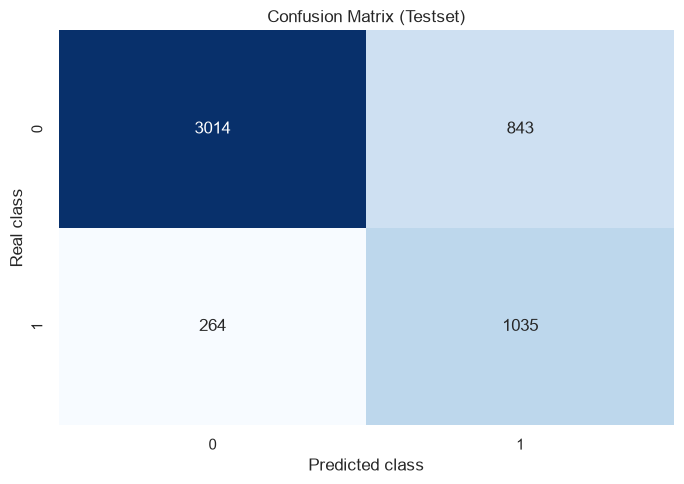

In [71]:
# Visualization – Confusion Matrix

y_pred_test = best_model.predict(X_test_scaled)

cm = confusion_matrix(
y_test,
y_pred_test
)

plt.figure(figsize=(7, 5))

sns.heatmap(
cm,
annot=True,
fmt="d",
cmap="Blues",
cbar=False
)

plt.title("Confusion Matrix (Testset)")
plt.xlabel("Predicted class")
plt.ylabel("Real class")

plt.tight_layout()
plt.show()

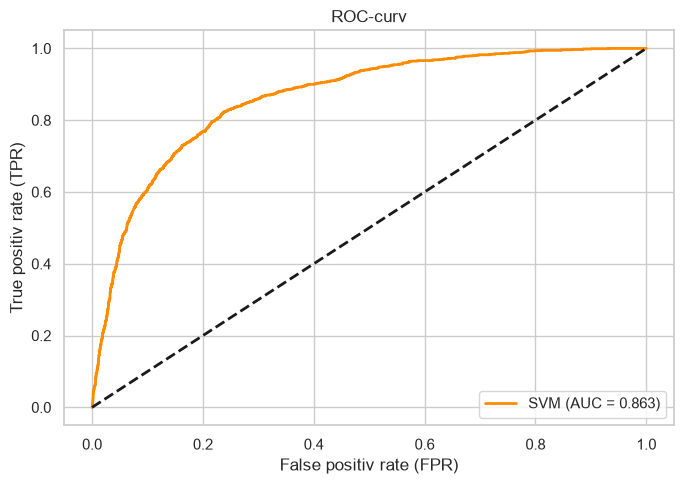

In [72]:
# Visualization – ROC Curve

y_prob_test = best_model.predict_proba(
X_test_scaled
)[:, 1]

fpr, tpr, thresholds = roc_curve(
y_test,
y_prob_test
)

auc_val = roc_auc_score(
y_test,
y_prob_test
)

plt.figure(figsize=(7, 5))

plt.plot(
fpr,
tpr,
label=f"SVM (AUC = {auc_val:.3f})",
color="darkorange",
lw=2
)

plt.plot(
[0, 1],
[0, 1],
"k--",
lw=2
)

plt.title("ROC-curv")
plt.xlabel("False positiv rate (FPR)")
plt.ylabel("True positiv rate (TPR)")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [73]:
# Business simulation on test set

df_test_eval = df_processed.loc[X_test.index].copy()

df_test_eval["predicted_optimal"] = y_pred_test

In [74]:
# 1. Average price selected by the model

model_avg_price = (
df_test_eval[
df_test_eval["predicted_optimal"] == 1
]["spot_price_eur_mwh"]
.mean()
)

In [75]:
# 2. Average price for actual optimal hours

actual_best_avg_price = (
df_test_eval[
df_test_eval["optimal_timme"] == 1
]["spot_price_eur_mwh"]
.mean()
)

In [76]:
# 3. Average price across the complete test set

total_avg_price = (
df_test_eval["spot_price_eur_mwh"]
.mean()
)

In [77]:
# 4. Average price for non-optimal hours
worst_avg_price = (
df_test_eval[
df_test_eval["optimal_timme"] == 0
]["spot_price_eur_mwh"]
.mean()
)

print("--- Business Price Simulation (Testset) ---")

print(
f"The model's selected average price: "
f"{model_avg_price:.2f} EUR/MWh"
)

print(
f"Theoretically best average price: "
f"{actual_best_avg_price:.2f} EUR/MWh"
)

print(
f"The total test set's average price: "
f"{total_avg_price:.2f} EUR/MWh"
)

print(
f"Average price for non-optimal hours: "
f"{worst_avg_price:.2f} EUR/MWh"
)

print(
f"\nThe model saves about "
f"{total_avg_price - model_avg_price:.2f} EUR/MWh "
f"on average compared to not optimizing at all!"
)


--- Business Price Simulation (Testset) ---
The model's selected average price: 18.91 EUR/MWh
Theoretically best average price: 14.42 EUR/MWh
The total test set's average price: 35.21 EUR/MWh
Average price for non-optimal hours: 42.21 EUR/MWh

The model saves about 16.30 EUR/MWh on average compared to not optimizing at all!


In [78]:
# Save trained model, scaler and feature columns

models_dir = Path("../models_bin")
models_dir.mkdir(exist_ok=True)

In [79]:
# Save SVM model

joblib.dump(
best_model,
models_dir / "svm_optimal_classifier.joblib"
)

['..\\models_bin\\svm_optimal_classifier.joblib']

In [80]:
# Save scaler

joblib.dump(
scaler,
models_dir / "scaler.joblib"
)

['..\\models_bin\\scaler.joblib']

In [81]:
# Save feature columns

with open(
    models_dir / "feature_cols.json",
    "w"
) as f:
    json.dump(
        feature_cols,
        f,
        indent=4
    )

print("\nModel, scaler, and feature columns have been saved in:")
print(models_dir)


Model, scaler, and feature columns have been saved in:
..\models_bin
